In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet(r"..\data\anp_enriched.parquet")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 44560660 entries, 2007-07-30 to 2026-07-31
Data columns (total 26 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Valor Venda Dolar   float64       
 1   Valor Compra Dolar  float64       
 2   Close_BZ=F          float64       
 3   High_BZ=F           float64       
 4   Low_BZ=F            float64       
 5   Open_BZ=F           float64       
 6   Volume_BZ=F         int64         
 7   ipca                float64       
 8   pib_mensal          float64       
 9   selic               float64       
 10  Regiao - Sigla      object        
 11  Estado - Sigla      object        
 12  Municipio           object        
 13  Revenda             object        
 14  CNPJ da Revenda     object        
 15  Nome da Rua         object        
 16  Numero Rua          object        
 17  Complemento         object        
 18  Bairro              object        
 19  Cep                 object

In [4]:
df.columns

Index(['Valor Venda Dolar', 'Valor Compra Dolar', 'Close_BZ=F', 'High_BZ=F',
       'Low_BZ=F', 'Open_BZ=F', 'Volume_BZ=F', 'ipca', 'pib_mensal', 'selic',
       'Regiao - Sigla', 'Estado - Sigla', 'Municipio', 'Revenda',
       'CNPJ da Revenda', 'Nome da Rua', 'Numero Rua', 'Complemento', 'Bairro',
       'Cep', 'Produto', 'Data da Coleta', 'Valor de Venda', 'Valor de Compra',
       'Unidade de Medida', 'Bandeira'],
      dtype='object')

In [5]:
df['ano_mes'] = df['Data da Coleta'].dt.to_period('M')

PRODUTOS = ['GASOLINA', 'ETANOL', 'DIESEL', 'GLP']
EXOG     = ['Valor Venda Dolar', 'Close_BZ=F', 'ipca', 'pib_mensal', 'selic']
LABELS   = ['Dólar', 'Brent', 'IPCA', 'PIB', 'SELIC']

In [6]:
# Estatísticas descritivas por produto
for produto in PRODUTOS:
    dados = df[df['Produto'] == produto]['Valor de Venda'].dropna()

    media     = dados.mean()
    mediana   = dados.median()
    desvio    = dados.std()
    iqr       = dados.quantile(0.75) - dados.quantile(0.25)
    p10, p90  = dados.quantile(0.10), dados.quantile(0.90)
    skew      = dados.skew()

    print(f"\n{'='*50}")
    print(f"qtd amostral: {len(dados)}")
    print(f"Produto: {produto}")
    print(f"  Média:         R$ {media:.2f}")
    print(f"  Mediana:       R$ {mediana:.2f}  {'(média > mediana → skew+)' if media > mediana else ''}")
    print(f"  Desvio padrão: R$ {desvio:.2f}")
    print(f"  IQR:           R$ {iqr:.2f}")
    print(f"  P10 – P90:     R$ {p10:.2f} – R$ {p90:.2f}")
    print(f"  Skewness:      {skew:.3f}")


qtd amostral: 10591170
Produto: GASOLINA
  Média:         R$ 4.69
  Mediana:       R$ 4.50  (média > mediana → skew+)
  Desvio padrão: R$ 1.39
  IQR:           R$ 2.29
  P10 – P90:     R$ 2.72 – R$ 6.49
  Skewness:      0.086

qtd amostral: 9373955
Produto: ETANOL
  Média:         R$ 3.34
  Mediana:       R$ 3.29  (média > mediana → skew+)
  Desvio padrão: R$ 1.08
  IQR:           R$ 1.69
  P10 – P90:     R$ 1.90 – R$ 4.79
  Skewness:      0.149

qtd amostral: 5799414
Produto: DIESEL
  Média:         R$ 3.83
  Mediana:       R$ 3.45  (média > mediana → skew+)
  Desvio padrão: R$ 1.63
  IQR:           R$ 3.13
  P10 – P90:     R$ 2.00 – R$ 6.34
  Skewness:      0.696

qtd amostral: 8280860
Produto: GLP
  Média:         R$ 67.79
  Mediana:       R$ 65.00  (média > mediana → skew+)
  Desvio padrão: R$ 27.74
  IQR:           R$ 42.00
  P10 – P90:     R$ 35.90 – R$ 110.00
  Skewness:      0.596


In [7]:
def bootstrap_erro_padrao(serie, n_bootstrap=1000, tamanho_amostra=60000):
    """
    Estima o erro padrão da média via bootstrap.
    Capítulo 2: simula a distribuição amostral sem assumir normalidade.
    """
    medias = []
    serie  = serie.dropna().values

    for _ in range(n_bootstrap):
        amostra = np.random.choice(serie, size=tamanho_amostra, replace=True)
        medias.append(np.mean(amostra))

    return np.std(medias)  # erro padrão = desvio padrão das médias bootstrap

# Erro padrão por produto
print(f"\n{'Produto':<25} {'Média (R$)':>12} {'EP Bootstrap':>14} {'CV (%)':>8}")
print("-" * 65)

for produto in PRODUTOS:
    dados = df[df['Produto'] == produto]['Valor de Venda'].dropna()
    media = dados.mean()
    ep    = bootstrap_erro_padrao(dados)
    cv    = (ep / media) * 100  # coeficiente de variação

    print(f"{produto:<25} {media:>12.2f} {ep:>14.4f} {cv:>8.2f}%")


Produto                     Média (R$)   EP Bootstrap   CV (%)
-----------------------------------------------------------------
GASOLINA                          4.69         0.0055     0.12%
ETANOL                            3.34         0.0045     0.13%
DIESEL                            3.83         0.0068     0.18%
GLP                              67.79         0.1122     0.17%


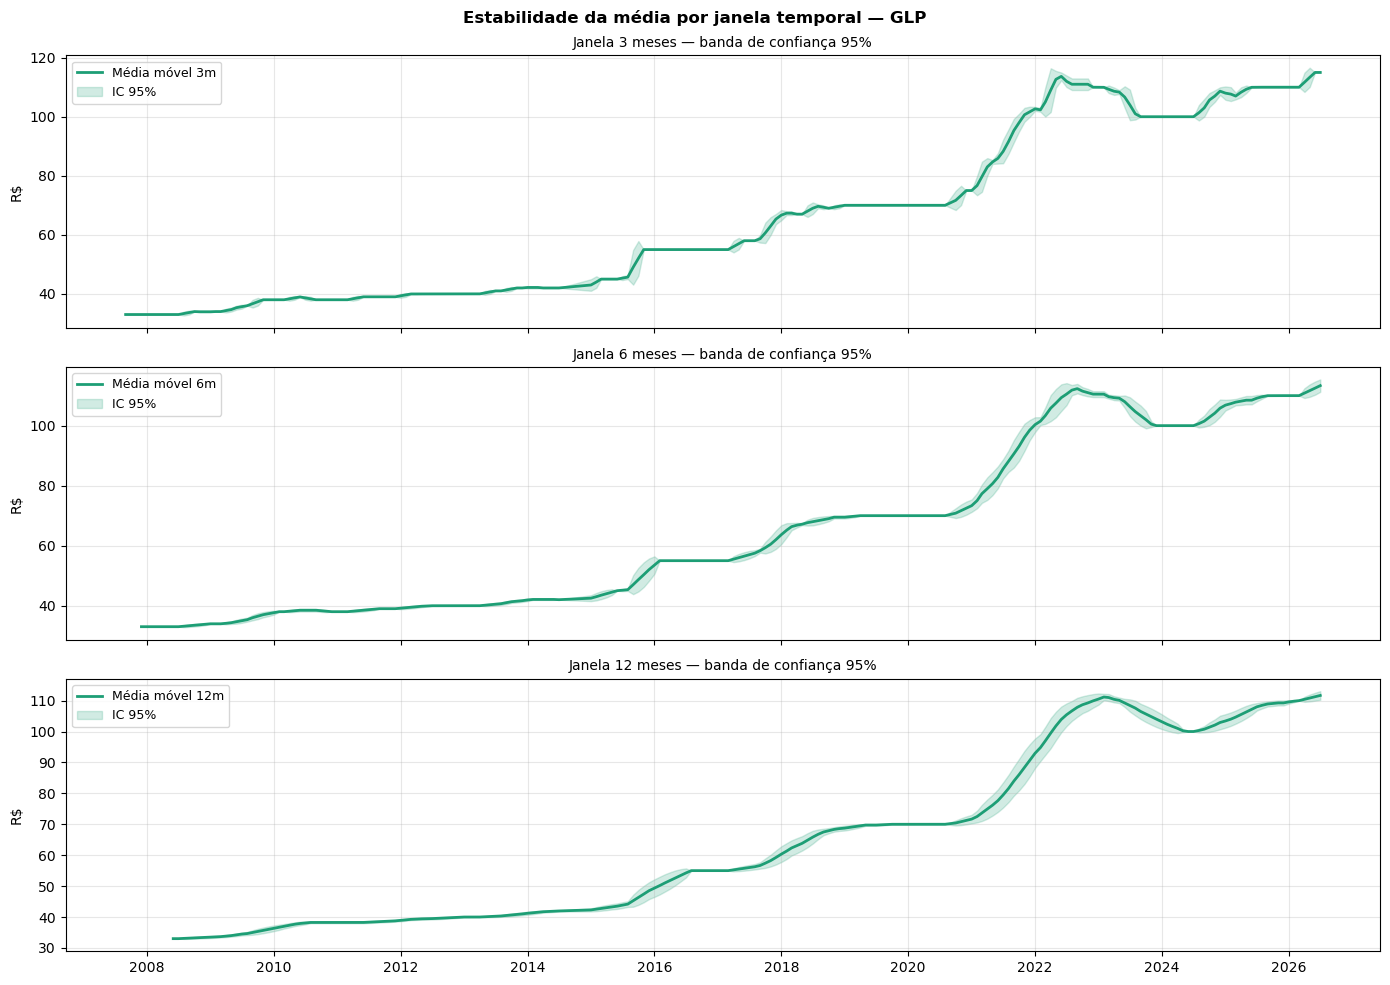

In [8]:
produto_foco = 'GLP'

dados_produto = (
    df[df['Produto'] == produto_foco]
    .groupby('ano_mes')['Valor de Venda']
    .median()
    .reset_index()
    .sort_values('ano_mes')
)
dados_produto['ano_mes_dt'] = dados_produto['ano_mes'].dt.to_timestamp()
serie = dados_produto['Valor de Venda'].values

# Calcula média e EP para janelas de 3, 6 e 12 meses
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, janela in zip(axes, [3, 6, 12]):
    medias_janela = pd.Series(serie).rolling(janela).mean()
    ep_janela     = pd.Series(serie).rolling(janela).std() / np.sqrt(janela)

    ax.plot(dados_produto['ano_mes_dt'], medias_janela,
            color='#1D9E75', lw=2, label=f'Média móvel {janela}m')
    ax.fill_between(
        dados_produto['ano_mes_dt'],
        medias_janela - 1.96 * ep_janela,
        medias_janela + 1.96 * ep_janela,
        alpha=0.2, color='#1D9E75', label='IC 95%'
    )
    ax.set_ylabel('R$')
    ax.set_title(f'Janela {janela} meses — banda de confiança 95%', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(f'Estabilidade da média por janela temporal — {produto_foco}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('janelas_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

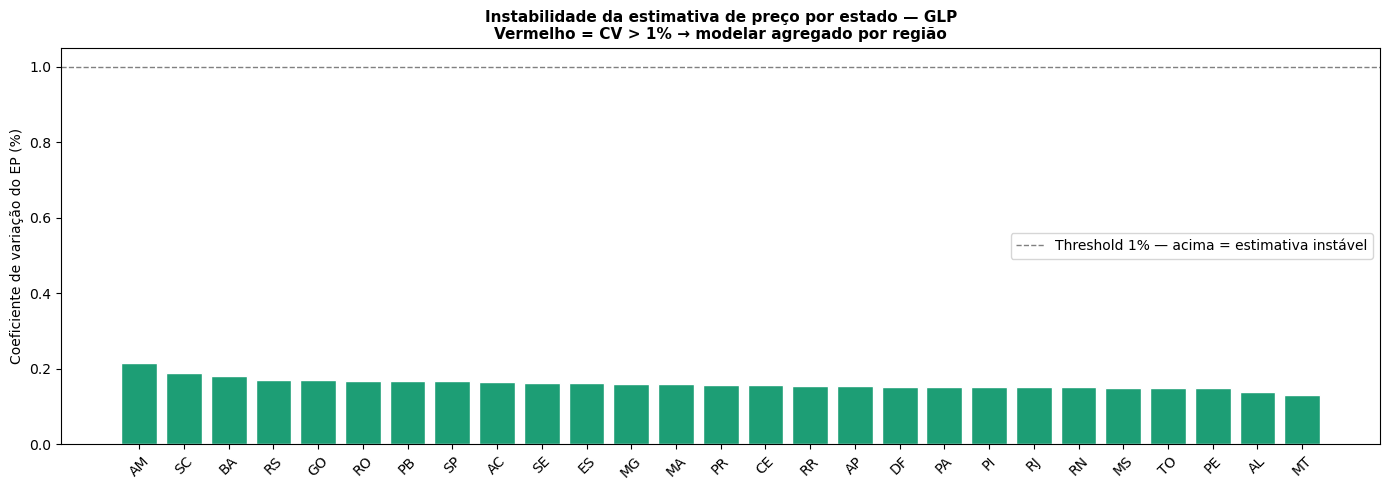

estado     media       ep       cv       n
    AM 74.464521 0.160805 0.215949  161528
    SC 68.545950 0.129594 0.189062  229034
    BA 65.431383 0.118165 0.180594  355819
    RS 67.354877 0.114643 0.170207  685293
    GO 65.094463 0.110131 0.169186  430756
    RO 78.092256 0.130752 0.167432  111694
    PB 67.522603 0.112788 0.167037  113644
    SP 64.790584 0.108176 0.166963 1948732
    AC 73.723249 0.121154 0.164336   67283
    SE 72.646387 0.117833 0.162200   52426
    ES 65.036308 0.104703 0.160992  194240
    MG 66.641892 0.106546 0.159878  975591
    MA 76.509359 0.121324 0.158574  141382
    PR 65.974660 0.103859 0.157422  707298
    CE 66.826621 0.104517 0.156400  240091
    RR 91.729538 0.142495 0.155342   47315
    AP 80.396309 0.123152 0.153181   31001
    DF 65.436506 0.099908 0.152680  103868
    PA 72.751961 0.110879 0.152406  258522
    PI 72.884030 0.110980 0.152269   78808
    RJ 66.409986 0.100671 0.151590  400741
    RN 71.413463 0.107961 0.151177   78489
    MS 69.2

In [9]:
produto_foco = 'GLP'

resultado_estados = []

for estado in df['Estado - Sigla'].unique():
    dados = df[
        (df['Produto'] == produto_foco) &
        (df['Estado - Sigla'] == estado)
    ]['Valor de Venda'].dropna()

    if len(dados) < 500:  # ignora estados com poucos dados
        continue

    media = dados.mean()
    ep    = bootstrap_erro_padrao(dados, n_bootstrap=500)
    cv    = (ep / media) * 100

    resultado_estados.append({
        'estado': estado,
        'media': media,
        'ep': ep,
        'cv': cv,
        'n': len(dados)
    })

df_estados = pd.DataFrame(resultado_estados).sort_values('cv', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))

cores = ['#D85A30' if cv > 1 else '#1D9E75' for cv in df_estados['cv']]
ax.bar(df_estados['estado'], df_estados['cv'], color=cores, edgecolor='white')
ax.axhline(1.0, color='gray', linestyle='--', lw=1,
           label='Threshold 1% — acima = estimativa instável')
ax.set_ylabel('Coeficiente de variação do EP (%)')
ax.set_title(
    f'Instabilidade da estimativa de preço por estado — {produto_foco}\n'
    'Vermelho = CV > 1% → modelar agregado por região',
    fontsize=11, fontweight='bold'
)
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('ep_estados.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_estados.to_string(index=False))

Decisao: segmentar o modelo por estado (pq se levarmos em consideracao o custo logistico/impostos são !=, mesmo se formos clusteriza-los.), o EP se torna uma variavel importante, pois um estado com EP historicamente alto sinaliza mercado volátil, e isso é informação preditiva real.

Um modelo por combinação:
estado (27) × produto (4) = até 108 modelos

Cada modelo recebe:
- Série temporal do preço médio (diário ou semanal)
- Features de lag        → definidas pelo PACF
- Features de janela     → definidas pela estabilidade do EP
- EP como feature        → volatilidade histórica do mercado
- Variáveis exógenas     → Dólar, Brent, IPCA, SELIC, PIB (com lag próprio)

In [10]:
# limpando columns desnecessarias - O 'Valor de Compra' nao vale a pena manter, pois os registros são antigos,
# logo tentar fazer um fill ou prever pode se tornar um ruido drastico na previsao da venda.

columns_utils = ['Produto', 'Valor de Venda','Data da Coleta','Estado - Sigla', 'Bandeira', 
                 'Valor Venda Dolar', 'Valor Compra Dolar', 'Close_BZ=F', 'High_BZ=F',
                'Low_BZ=F', 'Open_BZ=F', 'Volume_BZ=F', 'ipca', 'pib_mensal', 'selic',]
df = df[columns_utils]

In [11]:
df['dt_week'] = df['Data da Coleta'].dt.to_period('W')

df = df.dropna(how='any')

# Filtrando os produtos somente pelo aqueles que iremos utilizar.
df = df[df['Produto'].isin(['GASOLINA','GLP','ETANOL','DIESEL'])]

In [12]:
semanas = df.groupby(['dt_week','Estado - Sigla','Produto' ])['Valor de Venda'].median()
semana_df = semanas.reset_index()

Validando a completude dos dados semanais

In [13]:
semana_df[(semana_df['Estado - Sigla'] == 'SP') & (semana_df['Produto'] == 'GLP')].head()

,dt_week,Estado - Sigla,Produto,Valor de Venda
25,2007-07-30/2007-08-05,SP,GLP,32.0
52,2007-08-06/2007-08-12,SP,GLP,32.0
79,2007-08-13/2007-08-19,SP,GLP,32.0
106,2007-08-20/2007-08-26,SP,GLP,32.0
133,2007-08-27/2007-09-02,SP,GLP,32.0


In [14]:
ESTADOS = [
    'SP', 'MG', 'RJ', 'RS', 'PR', 'BA', 'GO', 'SC', 'PE', 'CE', 
    'PA', 'ES', 'MT', 'MA', 'MS', 'AM', 'PB', 'RN', 'RO', 'PI', 
    'DF', 'AL', 'TO', 'SE', 'AC', 'RR', 'AP'
]
for estado in ESTADOS:
    n = semana_df[
        (semana_df['Estado - Sigla'] == estado) &
        (semana_df['Produto'] == 'GLP')
    ].shape[0]
    print(f"{estado}: {n} semanas de 909")

SP: 949 semanas de 909
MG: 949 semanas de 909
RJ: 949 semanas de 909
RS: 949 semanas de 909
PR: 949 semanas de 909
BA: 949 semanas de 909
GO: 947 semanas de 909
SC: 947 semanas de 909
PE: 949 semanas de 909
CE: 945 semanas de 909
PA: 943 semanas de 909
ES: 946 semanas de 909
MT: 949 semanas de 909
MA: 948 semanas de 909
MS: 949 semanas de 909
AM: 945 semanas de 909
PB: 948 semanas de 909
RN: 943 semanas de 909
RO: 944 semanas de 909
PI: 949 semanas de 909
DF: 930 semanas de 909
AL: 945 semanas de 909
TO: 937 semanas de 909
SE: 936 semanas de 909
AC: 939 semanas de 909
RR: 943 semanas de 909
AP: 924 semanas de 909


In [15]:
# qtd de transicoes com buracos. Ou seja, o AP tem 22 semanas com gaps em todo o período de 2007 a 2026.
for estado in ESTADOS:
    _df = semana_df[(semana_df['Estado - Sigla'] == estado) & (semana_df['Produto'] == 'GLP')]
    _df['dt'] = _df['dt_week'].dt.start_time
    _df = _df.sort_values('dt')
    print(f'gaps {estado}: {len(_df[_df['dt'].diff().dt.days > 7])}')
    _df = ''

gaps SP: 7
gaps MG: 7
gaps RJ: 7
gaps RS: 7
gaps PR: 7
gaps BA: 7
gaps GO: 8
gaps SC: 8
gaps PE: 7
gaps CE: 9
gaps PA: 11
gaps ES: 9


C:\Users\ferna\AppData\Local\Temp\ipykernel_29276\801155247.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df['dt'] = _df['dt_week'].dt.start_time
C:\Users\ferna\AppData\Local\Temp\ipykernel_29276\801155247.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df['dt'] = _df['dt_week'].dt.start_time
C:\Users\ferna\AppData\Local\Temp\ipykernel_29276\801155247.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

gaps MT: 7
gaps MA: 8
gaps MS: 7
gaps AM: 10
gaps PB: 7
gaps RN: 11
gaps RO: 12
gaps PI: 7
gaps DF: 23
gaps AL: 10
gaps TO: 17
gaps SE: 18
gaps AC: 13
gaps RR: 13
gaps AP: 23


C:\Users\ferna\AppData\Local\Temp\ipykernel_29276\801155247.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df['dt'] = _df['dt_week'].dt.start_time
C:\Users\ferna\AppData\Local\Temp\ipykernel_29276\801155247.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  _df['dt'] = _df['dt_week'].dt.start_time
C:\Users\ferna\AppData\Local\Temp\ipykernel_29276\801155247.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

In [16]:
# aplicando ffill para completar as semanas faltantes
df_sp = semana_df[(semana_df['Estado - Sigla'] == 'SP') & (semana_df['Produto'] == 'GLP')]

In [17]:
week_complete_sp = pd.period_range(df_sp['dt_week'].min(),df_sp['dt_week'].max(),freq='W')

In [18]:
week_complete_sp

PeriodIndex(['2007-07-30/2007-08-05', '2007-08-06/2007-08-12',
             '2007-08-13/2007-08-19', '2007-08-20/2007-08-26',
             '2007-08-27/2007-09-02', '2007-09-03/2007-09-09',
             '2007-09-10/2007-09-16', '2007-09-17/2007-09-23',
             '2007-09-24/2007-09-30', '2007-10-01/2007-10-07',
             ...
             '2026-05-25/2026-05-31', '2026-06-01/2026-06-07',
             '2026-06-08/2026-06-14', '2026-06-15/2026-06-21',
             '2026-06-22/2026-06-28', '2026-06-29/2026-07-05',
             '2026-07-06/2026-07-12', '2026-07-13/2026-07-19',
             '2026-07-20/2026-07-26', '2026-07-27/2026-08-02'],
            dtype='period[W-SUN]', length=992)

In [19]:
# merge entre o df com o range completo entre as semanas com o df com os gaps
df_weeks = pd.DataFrame({'dt_week': week_complete_sp})
df_sp_comp = pd.merge(df_weeks, df_sp, on='dt_week', how='left')

# metodo ffill nas columns nan, para tornar continuo e poder realizar o ADF
df_sp_comp = df_sp_comp.ffill()

In [20]:
df_sp_comp.isna().sum()

dt_week           0
Estado - Sigla    0
Produto           0
Valor de Venda    0
dtype: int64

Validacoes feitas, agora iniciarei o teste de estacionariedade (ADF)

In [21]:
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(df_sp_comp['Valor de Venda'].dropna())


print(f"Estatística ADF: {resultado[0]:.4f}")
print(f"P-valor: {resultado[1]:.4f}")

Estatística ADF: 0.8473
P-valor: 0.9924


In [22]:
# aplicando a diff
df_sp_comp['Valor_Venda_diff'] = df_sp_comp['Valor de Venda'].diff()

In [23]:
resultado = adfuller(df_sp_comp['Valor_Venda_diff'].dropna())

print(f"Estatística ADF: {resultado[0]:.4f}")
print(f"P-valor: {resultado[1]:.4f}")

Estatística ADF: -16.4340
P-valor: 0.0000


valor ADF negativasso - logo a série temporal é estacionária.
p_value < 0,05, logo rejeita a Ho(hipótese nula) -> H_0 (Hipótese Nula): A série temporal NÃO é estacionária (possui uma "raiz unitária"). Isso significa que os dados têm uma tendência de subida/descida, variam muito ao longo do tempo e não têm uma média fixa.

Abaixo será feito uma análise de lags (ACF/PACF)

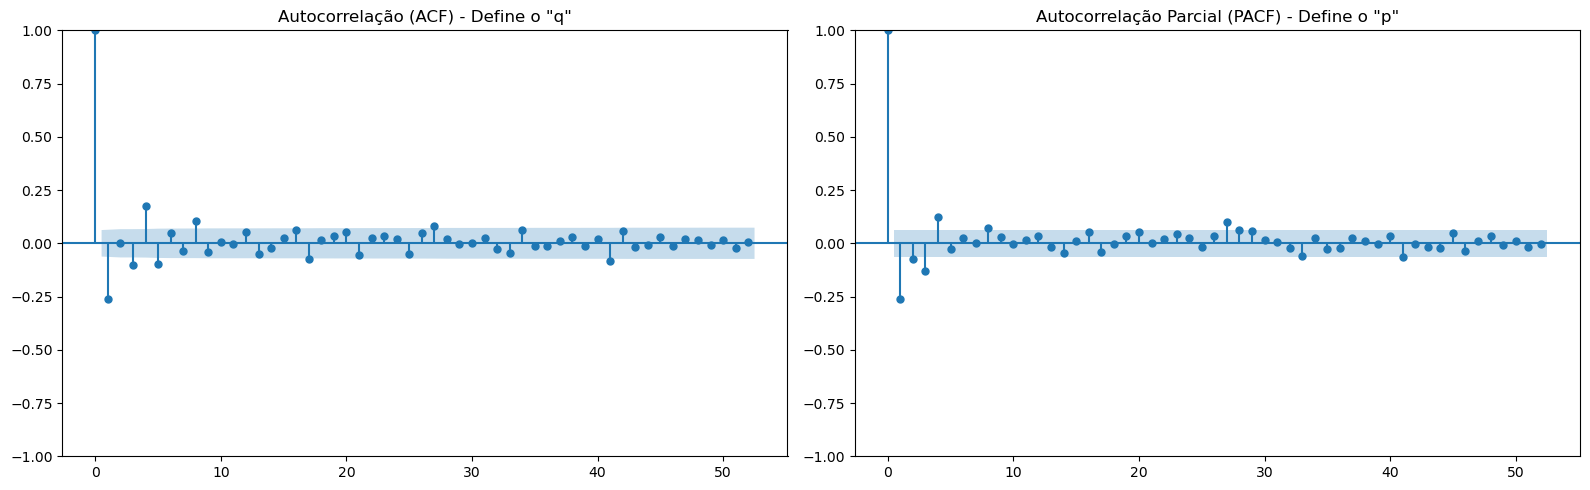

In [24]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import acf, pacf, plot_acf, plot_pacf

serie_estacionaria = df_sp_comp['Valor_Venda_diff'].dropna()

# 2. Configura o tamanho da imagem (1 linha, 2 colunas)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# 3. Plota o ACF no primeiro quadro (ax[0])
# Lags = 40 significa que vamos olhar a correlação com as últimas 52 semanas
plot_acf(serie_estacionaria, lags=52, ax=ax[0], title='Autocorrelação (ACF) - Define o "q"')

# 4. Plota o PACF no segundo quadro (ax[1])
plot_pacf(serie_estacionaria, lags=52, ax=ax[1], title='Autocorrelação Parcial (PACF) - Define o "p"')

# 5. Exibe os gráficos
plt.tight_layout()
plt.show()

In [25]:
# CORRIGIR E APLICAR THRESHOLD
serie_estacionaria = df_sp_comp['Valor_Venda_diff'].dropna()

threshold = 1.96 / np.sqrt(len(serie_estacionaria))

valores_acf = acf(serie_estacionaria, nlags=52)
valores_pacf = pacf(serie_estacionaria, nlags=52)

valores_limiar_acf = []
valores_limiar_pacf = []

for v in valores_pacf:
    if v > threshold: valores_limiar_pacf.append(v)
    else: pass


df_correlacoes = pd.DataFrame({
    'Lag': range(len(valores_acf)),
    'ACF': valores_acf,
    'PACF': valores_pacf
})

print(df_correlacoes)

    Lag       ACF      PACF
0     0  1.000000  1.000000
1     1 -0.263051 -0.263317
2     2  0.002411 -0.071905
3     3 -0.100651 -0.128755
4     4  0.176058  0.124876
5     5 -0.097653 -0.028916
6     6  0.048431  0.024308
7     7 -0.037905  0.000106
8     8  0.103704  0.074418
9     9 -0.038511  0.029594
10   10  0.004336 -0.002711
11   11 -0.003222  0.017515
12   12  0.051993  0.033200
13   13 -0.048508 -0.019164
14   14 -0.023629 -0.044933
15   15  0.025679  0.009179
16   16  0.060867  0.052412
17   17 -0.075564 -0.043259
18   18  0.014010 -0.002794
19   19  0.035195  0.035736
20   20  0.051564  0.053887
21   21 -0.053693  0.000449
22   22  0.024078  0.019513
23   23  0.033434  0.045102
24   24  0.022241  0.024998
25   25 -0.051133 -0.015833
26   26  0.049491  0.035281
27   27  0.083096  0.102285
28   28  0.021354  0.066079
29   29 -0.004974  0.059651
30   30  0.000070  0.016458
31   31  0.024904  0.007504
32   32 -0.024539 -0.023759
33   33 -0.047408 -0.061826
34   34  0.062370  0

In [31]:
df_sp_comp.head()

,dt_week,Estado - Sigla,Produto,Valor de Venda,Valor_Venda_diff
0,2007-07-30/2007-08-05,SP,GLP,32.0,NaN
1,2007-08-06/2007-08-12,SP,GLP,32.0,0.0
2,2007-08-13/2007-08-19,SP,GLP,32.0,0.0
3,2007-08-20/2007-08-26,SP,GLP,32.0,0.0
4,2007-08-27/2007-09-02,SP,GLP,32.0,0.0


In [26]:
df_resultados = pd.DataFrame({
    'Lag': range(52 + 1),
    'ACF': valores_acf,
    'ACF_Relevante': np.abs(valores_acf) > threshold,
    'PACF': valores_pacf,
    'PACF_Relevante': np.abs(valores_pacf) > threshold
})

print(f"Tamanho da amostra (N): {len(serie_estacionaria)}")
print(f"Limiar de significância (Threshold): ±{threshold:.4f}\n")
display(df_resultados)

Tamanho da amostra (N): 991
Limiar de significância (Threshold): ±0.0623



,Lag,ACF,ACF_Relevante,PACF,PACF_Relevante
0,0,1.000000,True,1.000000,True
1,1,-0.263051,True,-0.263317,True
2,2,0.002411,False,-0.071905,True
3,3,-0.100651,True,-0.128755,True
4,4,0.176058,True,0.124876,True
5,5,-0.097653,True,-0.028916,False
6,6,0.048431,False,0.024308,False
7,7,-0.037905,False,0.000106,False
8,8,0.103704,True,0.074418,True
9,9,-0.038511,False,0.029594,False


In [27]:
# validando os PACF e definindo quais lags entrarao no modelo
pacf = df_resultados[df_resultados['PACF_Relevante'] == True]
pacf[['Lag', 'PACF','PACF_Relevante']]

,Lag,PACF,PACF_Relevante
0,0,1.000000,True
1,1,-0.263317,True
2,2,-0.071905,True
3,3,-0.128755,True
4,4,0.124876,True
8,8,0.074418,True
27,27,0.102285,True
28,28,0.066079,True
41,41,-0.066183,True


- lag_1   →  reversão de curto prazo (mais forte)
- lag_2   →  continuação do ajuste de curto prazo
- lag_3   →  fim do ciclo de ajuste semanal
- lag_4   →  início do ciclo mensal (inverte sinal)
- lag_8   →  ciclo bimestral / reposição de estoque
- lag_27  →  sazonalidade semestral
------------------------------------------------
Os lags 29 e 33 têm PACF muito próximo do threshold (0.068 e -0.081 contra um limite de 0.0628) — a diferença é pequena o suficiente para ser ruído estatístico em vez de sinal real.

#### definindo janelas

In [29]:
df_resultados.head()

,Lag,ACF,ACF_Relevante,PACF,PACF_Relevante
0,0,1.000000,True,1.000000,True
1,1,-0.263051,True,-0.263317,True
2,2,0.002411,False,-0.071905,True
3,3,-0.100651,True,-0.128755,True
4,4,0.176058,True,0.124876,True


In [33]:
from scipy import stats

# Testa várias janelas, não só 4 e 8
janelas_teste = [2, 4, 6, 8, 12, 16]

resultados = []

for produto in ['GLP', 'GASOLINA', 'ETANOL', 'DIESEL', ]:
    dados = df_sp_comp[df_sp_comp['Produto'] == produto].sort_values(['Estado - Sigla', 'dt_week'])
    
    for janela in janelas_teste:
        rolling = (
            dados.groupby('Estado - Sigla')['Valor de Venda']
            .transform(lambda x: x.shift(1).rolling(window=janela).mean())
        )
        
        # Correlação entre a rolling mean e o preço da semana seguinte
        preco_futuro = dados.groupby('Estado - Sigla')['Valor de Venda'].shift(-1)
        
        validos = rolling.notna() & preco_futuro.notna()
        rho, p = stats.spearmanr(rolling[validos], preco_futuro[validos])
        
        resultados.append({
            'produto': produto,
            'janela': janela,
            'rho': rho,
            'pvalue': p
        })

df_janelas = pd.DataFrame(resultados)
pivot = df_janelas.pivot(index='janela', columns='produto', values='rho')
print(pivot)

produto  DIESEL  ETANOL  GASOLINA       GLP
janela                                     
2           NaN     NaN       NaN  0.997651
4           NaN     NaN       NaN  0.997189
6           NaN     NaN       NaN  0.996703
8           NaN     NaN       NaN  0.996245
12          NaN     NaN       NaN  0.995472
16          NaN     NaN       NaN  0.994718
